# Fronts

This notebook is meant to help forcasters locate the position of fronts on a weather map

In [76]:
from herbie import Herbie
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.weight"] = "heavy"
from toolbox import EasyMap, pc
import cartopy.crs as ccrs
import cartopy.feature as feature
import pandas as pd

from matplotlib.patches import Rectangle
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pytz
import os, shutil
import json

from scipy.ndimage import gaussian_filter

import warnings

# supress because removal of old datafiles is handled outside herbie
warnings.filterwarnings("ignore")

from bmwflib import (
    clear_directory,
    get_var,
    make_figure,
    plot_cities,
    make_title,
    plot_pressure,
    find_pressure_centres,
)

%load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


In [145]:
# time of last model run (0Z and 12Z)
# now = pd.Timestamp.utcnow().floor("12h").tz_localize(None)
fxx = 6

# config determines the directories in which to save each graphic
with open("..//config/gdps_config.json") as f:
    config = json.load(f)

clear_dir = [clear_directory(file) for file in list(config["plots"].values())]

In [166]:
# heights to pull geopotentials
hgt = ["ISBL_1000", "ISBL_500"]

height = xr.concat(
    [get_var(now, "gdps", fxx, "HGT", h) for h in hgt],
    dim="isobaricInhPa",
)
pres = get_var(now, "gdps", fxx, "PRMSL", "MSL_0")
u = get_var(now, "gdps", fxx, "UGRD", "ISBL_500")
v = get_var(now, "gdps", fxx, "VGRD", "ISBL_500")
ds = xr.merge([pres, height, u, v])
# calculate 1000 - 500mb thickness
ds["thick"] = ds.gh.loc[{"isobaricInhPa": 500}] - ds.gh.loc[{"isobaricInhPa": 1000}]

✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None
✅ Found ┊ model=gdps ┊ product=15km/grib2/lat_lon ┊ 2025-Nov-09 12:00 UTC F06 ┊ GRIB2 @ local ┊ IDX @ None


In [147]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:              (latitude: 287, longitude: 554, isobaricInhPa: 2)
Coordinates:
    time                 datetime64[ns] 8B 2025-11-09T12:00:00
    step                 timedelta64[ns] 8B 06:00:00
    meanSea              float64 8B 0.0
  * latitude             (latitude) float64 2kB 30.0 30.15 30.3 ... 72.75 72.9
  * longitude            (longitude) float64 4kB -180.0 -179.8 ... -97.2 -97.05
    valid_time           datetime64[ns] 8B 2025-11-09T18:00:00
    gribfile_projection  object 8B None
  * isobaricInhPa        (isobaricInhPa) float64 16B 1e+03 500.0
Data variables:
    prmsl                (latitude, longitude) float32 636kB ...
    gh                   (isobaricInhPa, latitude, longitude) float32 1MB 156...
    u                    (latitude, longitude) float32 636kB ...
    v                    (latitude, longitude) float32 636kB ...
    thick                (latitude, longitude) float32 636kB 5.712e+03 ... 5....
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    model:                   gdps
    product:                 15km/grib2/lat_lon
    description:             Canada's Global Deterministic Prediction System ...
    remote_grib:             /Users/andrew/data/gdps/20251109/CMC_glb_PRMSL_M...
    local_grib:              /Users/andrew/data/gdps/20251109/CMC_glb_PRMSL_M...
    search:                  None

We want to find areas where there is steep intersection angle between isobars and lines of constant thickness. do this by taking the dot product of the gradients and comparing to some threshhold angle:

$$
\frac{\nabla geopotential \cdot \nabla thickness}{\lvert \nabla geopotential \rvert \lvert \nabla thickness \rvert} < \theta_t
$$

Warm air advection is when the dot product of the wind vector and temp gradient is less than zero, cold air advection is the opposite.

In [167]:
# gaussian filter to eliminate spurious small scale "fronts"
filter_width = 5
# gh_500 = gaussian_filter(np.array(ds.gh.loc[{"isobaricInhPa": 500}]), filter_width)
# thick = gaussian_filter(ds.thick, filter_width)

gh_500 = ds.gh.loc[{"isobaricInhPa": 500}]
thick = ds.thick

# calculate the gradient of the 500mb geopotential surface and its magnitude
grad_500 = np.gradient(gh_500)
mag_500 = (grad_500[0] ** 2 + grad_500[1] ** 2) ** 0.5

# calculate the gradient of 1000-500mb thickness and its magnitude
grad_thick = np.gradient(thick)
mag_thick = (grad_thick[0] ** 2 + grad_thick[1] ** 2) ** 0.5

# get the dot product of thickness gradient and geopotential gradient, then get the angle between gradients
dot = grad_500[0] * grad_thick[0] + grad_500[1] * grad_thick[1]
theta = np.arccos(dot / (mag_500 * mag_thick))

# calculate warm and cold air advection zones
mag_wind = (ds.u ** 2 + ds.v ** 2) ** 0.5
ds["adv"] = (ds.u * grad_thick[0] + ds.v * grad_thick[1]) / (mag_wind * mag_thick)

# convert to xarray
ds["thick"] = xr.DataArray(thick, coords=(ds.latitude, ds.longitude))
ds["mag_thick"] = xr.DataArray(mag_thick, coords=(ds.latitude, ds.longitude))

ds["theta"] = xr.DataArray(theta, coords=(ds.latitude, ds.longitude))

<a list of 19 text.Text objects>

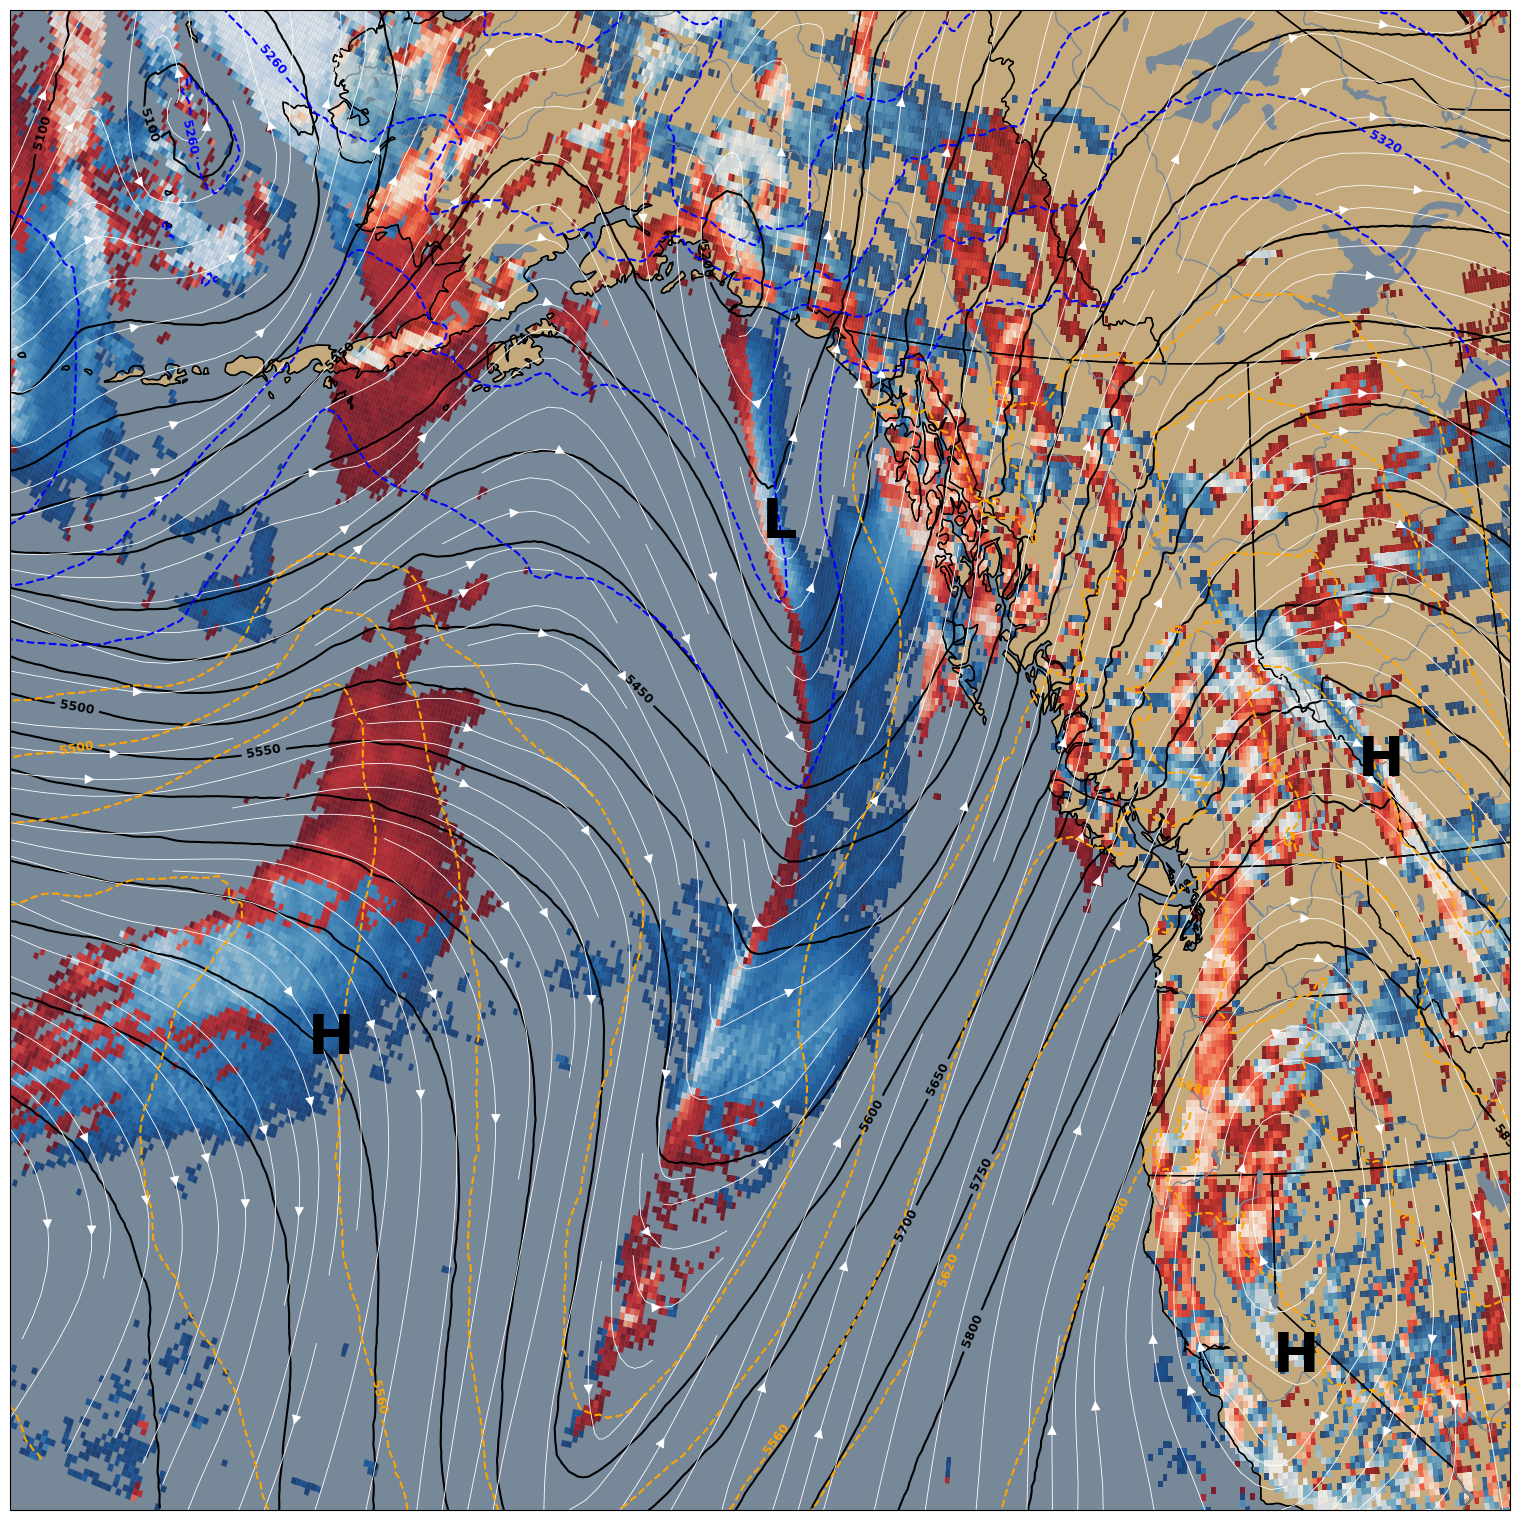

In [182]:
fig, ax = make_figure()

# plot 500mb pressure
plot_pressure(
    ds.gh.loc[{"isobaricInhPa": 500}],
    ax,
    "MWF",
    radius=90,
    delrad=40,
    levels=range(0, 8000, 50),
)

# plot wind streamlines
strm = ax.streamplot(
    ds.longitude,
    ds.latitude,
    ds.u,
    ds.v,
    transform=pc,
    color="white",
    density=2,
    linewidth=0.6,
    arrowsize=1.5,
)

# plot areas where the angle bw thickness and height is > theta
theta = 40
# cold fronts (advection > 0)
c = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.theta.where(
        (ds.theta >= theta * (np.pi / 180))
        & (ds.theta <= (180 - theta * (np.pi / 180)))
        & (ds.adv > 0)
    ),
    cmap="Blues_r",
    antialiased=True,
    transform=pc,
    alpha=0.8,
)

# warm fronts (advection < 0)
w = ax.pcolormesh(
    ds.longitude,
    ds.latitude,
    ds.theta.where(
        (ds.theta >= theta * (np.pi / 180))
        & (ds.theta <= (180 - theta * (np.pi / 180)))
        & (ds.adv < 0)
    ),
    cmap="Reds_r",
    antialiased=True,
    transform=pc,
    alpha=0.8,
)
# plot thickness contours
th_cmap = mpl.colors.ListedColormap(
    [
        "pink",
        "blue",
        "orange",
    ]
)
th_bounds = [4800, 5100, 5400, 5700]
th_norm = mpl.colors.BoundaryNorm(th_bounds, th_cmap.N)
ht = ax.contour(
    ds.longitude,
    ds.latitude,
    ds.thick,
    cmap=th_cmap,
    norm=th_norm,
    linestyles="dashed",
    transform=pc,
    levels=range(4000, 6000, 60),
)
ax.clabel(ht, inline=True, fontsize=9)

In [169]:
vec1 = [1, 0]
mag1 = (vec1[0] ** 2 + vec1[1] ** 2) ** 0.5
vec2 = [-1, -1]
mag2 = (vec2[0] ** 2 + vec2[1] ** 2) ** 0.5


np.arccos((vec1[0] * vec2[0] + vec1[1] * vec2[1]) / (mag1 * mag2)) * 180 / np.pi

np.float64(135.0)